# Backend Floor Planner Workflow Test

Run this notebook before testing inside SketchUp. It calls the hosted backend over HTTP so the same backend logs used by SketchUp are exercised.

Coverage:
- backend health and route availability through the hosted API
- floor-plan discussion draft capture
- continued discussion with `temporary_floor_plan_draft`
- LLM-supported decoration JSON and floor-plan SVG plotting tools through `/agent/orchestrate`
- artifact download for generated decoration JSON, SVG, and PNG preview
- whole-plan two-option 16:9 panorama generation through direct `/generate/panorama` backend tool

In [87]:
import base64
import json
import os
import urllib.error
import urllib.request
import socket
from pathlib import Path

REPO_ROOT = Path.cwd()
BACKEND_ROOT = REPO_ROOT / "backend"
BACKEND_URL = os.getenv("BACKEND_URL", "http://127.0.0.1:8000").rstrip("/")
REQUEST_TIMEOUT_SECONDS = int(os.getenv("NOTEBOOK_REQUEST_TIMEOUT_SECONDS", "240"))
PANORAMA_TIMEOUT_SECONDS = int(os.getenv("NOTEBOOK_PANORAMA_TIMEOUT_SECONDS", "720"))

NOTEBOOK_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook-floor-plan"
NOTEBOOK_EXPORT_DIR = REPO_ROOT / "exports" / "notebook-floor-plan"
NOTEBOOK_POINTCLOUD_DIR = REPO_ROOT / "pointclouds" / "notebook-floor-plan"
NOTEBOOK_PANORAMA_DIR = NOTEBOOK_OUTPUT_DIR / "panorama"
NOTEBOOK_ROOM_RENDER_DIR = NOTEBOOK_OUTPUT_DIR / "room_render"
for path in (NOTEBOOK_OUTPUT_DIR, NOTEBOOK_EXPORT_DIR, NOTEBOOK_POINTCLOUD_DIR, NOTEBOOK_ROOM_RENDER_DIR, NOTEBOOK_PANORAMA_DIR):
    path.mkdir(parents=True, exist_ok=True)

assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY is required because FloorPlanPlotTool owns SVG plotting."

class ApiResponse:
    def __init__(self, status_code: int, body: bytes):
        self.status_code = status_code
        self.content = body
        self.text = body.decode("utf-8", errors="replace")

    def json(self):
        return json.loads(self.text)


class HostedBackendClient:
    def __init__(self, base_url: str):
        self.base_url = base_url

    def get(self, path: str, timeout_seconds: int = REQUEST_TIMEOUT_SECONDS) -> ApiResponse:
        return self._request("GET", path, timeout_seconds=timeout_seconds)

    def post(self, path: str, json_body: dict, timeout_seconds: int = REQUEST_TIMEOUT_SECONDS) -> ApiResponse:
        return self._request("POST", path, json_body, timeout_seconds=timeout_seconds)

    def _request(self, method: str, path: str, json_body: dict | None = None, timeout_seconds: int = REQUEST_TIMEOUT_SECONDS) -> ApiResponse:
        body = None if json_body is None else json.dumps(json_body).encode("utf-8")
        headers = {} if body is None else {"Content-Type": "application/json"}
        request = urllib.request.Request(f"{self.base_url}{path}", data=body, headers=headers, method=method)
        try:
            with urllib.request.urlopen(request, timeout=timeout_seconds) as response:
                return ApiResponse(response.status, response.read())
        except urllib.error.HTTPError as exc:
            return ApiResponse(exc.code, exc.read())
        except TimeoutError as exc:
            raise TimeoutError(f"{method} {path} exceeded {timeout_seconds}s. Check backend logs with: docker compose logs -f backend") from exc
        except socket.timeout as exc:
            raise TimeoutError(f"{method} {path} exceeded {timeout_seconds}s. Check backend logs with: docker compose logs -f backend") from exc


client = HostedBackendClient(BACKEND_URL)
print("Backend URL:", BACKEND_URL)
print("Watch backend logs with: docker compose logs -f backend")
print("Backend root:", BACKEND_ROOT)
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)
print("Default request timeout seconds:", REQUEST_TIMEOUT_SECONDS)
print("Panorama request timeout seconds:", PANORAMA_TIMEOUT_SECONDS)


Backend URL: http://127.0.0.1:8000
Watch backend logs with: docker compose logs -f backend
Backend root: /Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/backend
Notebook output dir: /Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan
Default request timeout seconds: 240
Panorama request timeout seconds: 720


## 1. Backend Health And Routes

In [88]:
health = client.get("/health")
assert health.status_code == 200
assert health.json() == {"status": "ok"}

openapi = client.get("/openapi.json")
assert openapi.status_code == 200, openapi.text
routes = set(openapi.json()["paths"].keys())
required_routes = {
    "/agent/orchestrate",
    "/generate/panorama",
    "/artifacts/download",
}
assert required_routes.issubset(routes), sorted(required_routes - routes)

{"health": health.json(), "routes_checked": sorted(required_routes)}


{'health': {'status': 'ok'},
 'routes_checked': ['/agent/orchestrate',
  '/artifacts/download',
  '/generate/panorama']}

## 2. Shared Render Payload Helper

In [89]:
def valid_render_payload(user_prompt: str) -> dict:
    return {
        "project_id": "notebook-floor-plan",
        "viewport_image_path": "notebook_view.png",
        "style": "modern interior",
        "user_prompt": user_prompt,
        "camera": {
            "position": [1.2, 3.4, 2.1],
            "direction": [0.0, 1.0, -0.2],
            "fov": 45,
        },
        "model": {
            "bounds": {"width": 8.2, "depth": 6.4, "height": 3.1},
            "materials": ["wood", "glass", "concrete"],
            "selected_entity_count": 0,
        },
        "render_options": {
            "preserve_geometry": True,
            "preserve_camera": True,
            "output_resolution": "1024x1024",
        },
    }


## 3. Discussion Draft Capture

This tests the backend discussion step that SketchUp uses before showing `Plot Floor Plan`.

In [90]:
discussion_payload = valid_render_payload(
    "Floor plan for " \
    "1. Living with front door, width 10, height 20, " \
    "2. Kitchen with width 10, height 10, " \
    "3. Office with width 10, height 10. " \
    "4. Living has door to Office, but no door to Kitchen. "\
    "5. A wall between Kitchen and Office."
    "6. Connection (Living, Kitchen), (Living, Office). "
    "7. Must be rectangular shape. "
)
discussion_response = client.post("/agent/orchestrate", json_body=discussion_payload)
assert discussion_response.status_code == 200, discussion_response.text
discussion = discussion_response.json()

assert discussion["intent"] == "floor_plan_discuss"
assert discussion["assigned_agent"] == "FloorPlanDiscussionAgent"
assert discussion["floor_plan_ready"] is True
assert discussion["floor_plan_missing_fields"] == []
assert discussion["floor_plan_draft"]["rooms"]

floor_plan_draft = discussion["floor_plan_draft"]
{"rooms": floor_plan_draft["rooms"], "ready": discussion["floor_plan_ready"]}


{'rooms': [{'name': 'Living',
   'width': 10.0,
   'depth': 20.0,
   'label': 'Living Room'},
  {'name': 'Kitchen', 'width': 10.0, 'depth': 10.0, 'label': 'Kitchen'},
  {'name': 'Office', 'width': 10.0, 'depth': 10.0, 'label': 'Office'}],
 'ready': True}

## 4. Continued Discussion With Existing Draft State

This mirrors the dialog sending `temporary_floor_plan_draft` on the next chat turn.

In [91]:
# continued_payload = valid_render_payload("Office 20x10 connected to Kitchen")
# continued_payload["temporary_floor_plan_draft"] = floor_plan_draft
# continued_response = client.post("/agent/orchestrate", json_body=continued_payload)
# assert continued_response.status_code == 200, continued_response.text
# continued = continued_response.json()

# assert continued["intent"] == "floor_plan_discuss"
# assert continued["floor_plan_ready"] is True

# floor_plan_draft = continued["floor_plan_draft"]
room_names = [room["name"] for room in floor_plan_draft["rooms"]]
assert room_names == ["Living", "Kitchen", "Office"], room_names
room_names


['Living', 'Kitchen', 'Office']

## 5. Plot Through `/agent/orchestrate`

This mirrors clicking `Plot Floor Plan` in SketchUp.

In [92]:
plot_payload = valid_render_payload("plot the floor plan")
plot_payload["temporary_floor_plan_draft"] = floor_plan_draft
plot_response = client.post("/agent/orchestrate", json_body=plot_payload)
assert plot_response.status_code == 200, plot_response.text
plot = plot_response.json()

assert plot["intent"] == "floor_plan_plot"
assert plot["assigned_agent"] == "FloorPlanToolchain"
assert plot["floor_plan_ready"] is True
assert plot["floor_plan"]["svg_path"].endswith(".svg")
assert plot["floor_plan"]["preview_image_path"].endswith(".png")
assert plot["floor_plan"]["decoration_path"].endswith(".layout.json")
assert [artifact["type"] for artifact in plot["artifacts"]] == ["floor_plan_svg", "floor_plan_png", "floor_plan_decoration_json"]

svg_path = plot["floor_plan"]["svg_path"]
png_path = plot["floor_plan"]["preview_image_path"]
decoration_path = plot["floor_plan"]["decoration_path"]
assert svg_path.endswith(".svg"), svg_path
assert png_path.endswith(".png"), png_path
assert decoration_path.endswith(".layout.json"), decoration_path

plot["floor_plan"]


{'status': 'success',
 'artifact_id': 'floorplan_20260516_142831_ecd3f7d2',
 'svg_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.svg',
 'preview_image_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.png',
 'decoration_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.layout.json',
 'room_count': 3,
 'warnings': [],
 'error_message': None}

## 6. Artifact Download Endpoint

In [93]:
svg_download = client.post("/artifacts/download", json_body={"path": svg_path})
png_download = client.post("/artifacts/download", json_body={"path": png_path})
decoration_download = client.post("/artifacts/download", json_body={"path": decoration_path})
assert svg_download.status_code == 200, svg_download.text
assert png_download.status_code == 200, png_download.text
assert decoration_download.status_code == 200, decoration_download.text

svg_bytes = base64.b64decode(svg_download.json()["content_base64"])
png_bytes = base64.b64decode(png_download.json()["content_base64"])
decoration_bytes = base64.b64decode(decoration_download.json()["content_base64"])
assert svg_bytes.startswith(b"<svg")
assert png_bytes.startswith(b"\x89PNG")
decoration = json.loads(decoration_bytes.decode("utf-8"))
assert decoration["decorated_layout"]["rooms"]
assert decoration["decorated_layout"]["doors"]
assert decoration["decorated_layout"]["furniture"]

local_svg_path = NOTEBOOK_OUTPUT_DIR / Path(svg_path).name
local_png_path = NOTEBOOK_OUTPUT_DIR / Path(png_path).name
local_decoration_path = NOTEBOOK_OUTPUT_DIR / Path(decoration_path).name
local_svg_path.write_bytes(svg_bytes)
local_png_path.write_bytes(png_bytes)
local_decoration_path.write_bytes(decoration_bytes)

{
    "svg_size_bytes": len(svg_bytes),
    "png_size_bytes": len(png_bytes),
    "decoration_size_bytes": len(decoration_bytes),
    "backend_svg_path": svg_path,
    "backend_png_path": png_path,
    "backend_decoration_path": decoration_path,
    "local_svg_path": str(local_svg_path),
    "local_png_path": str(local_png_path),
    "local_decoration_path": str(local_decoration_path),
}


{'svg_size_bytes': 4655,
 'png_size_bytes': 10202,
 'decoration_size_bytes': 4205,
 'backend_svg_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.svg',
 'backend_png_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.png',
 'backend_decoration_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.layout.json',
 'local_svg_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.svg',
 'local_png_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.png',
 'local_decoration_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.layout.json'}

## 7. Display Floor Plan Before Panorama

This confirms the plotted floor plan visually before the panorama backend tool uses its decoration JSON.

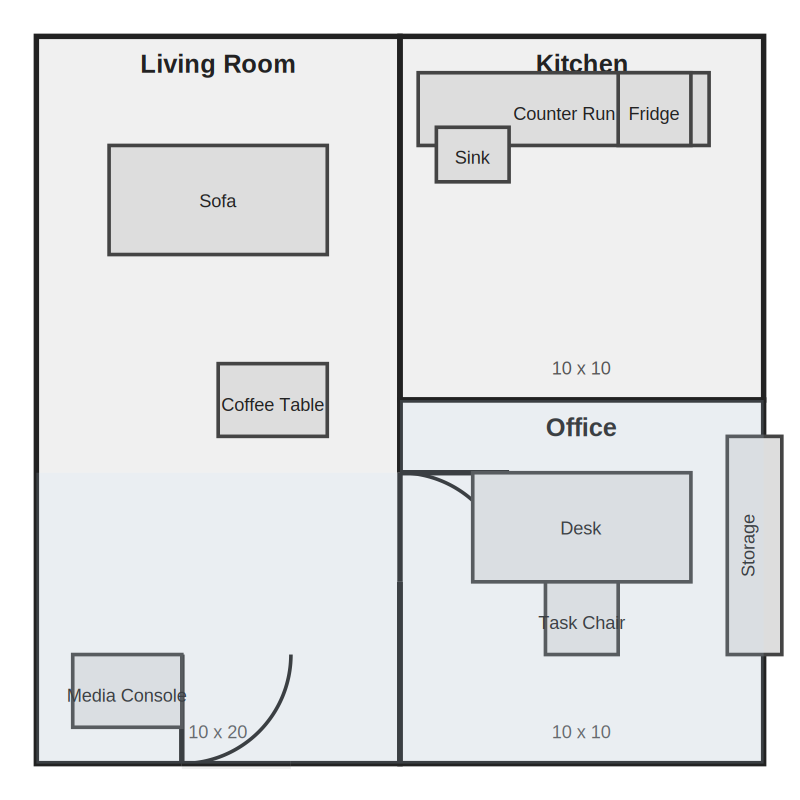

{'displayed_floor_plan': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.svg',
 'display_mode': 'svg',
 'authoritative_floor_plan_svg': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.svg',
 'panorama_decoration_path': '/app/outputs/floorplan_20260516_142831_ecd3f7d2.layout.json'}

In [94]:
from IPython.display import Image, SVG, display
from xml.parsers.expat import ExpatError

try:
    display(SVG(filename=str(local_svg_path)))
    floor_plan_display_path = local_svg_path
    floor_plan_display_mode = "svg"
except ExpatError:
    display(Image(filename=str(local_png_path)))
    floor_plan_display_path = local_png_path
    floor_plan_display_mode = "png_fallback"

{
    "displayed_floor_plan": str(floor_plan_display_path),
    "display_mode": floor_plan_display_mode,
    "authoritative_floor_plan_svg": str(local_svg_path),
    "panorama_decoration_path": decoration_path,
}


## 8. Generate Whole-Plan Panorama

This tests the direct backend panorama tool. It requires only the plotted floor-plan decoration JSON and must call `/generate/panorama` directly, not `/agent/orchestrate`.

In [95]:
panorama_payload = {
    "decoration_path": decoration_path,
    "style": "modern interior",
    "output_resolution": "1024x576",
}
panorama_response = client.post("/generate/panorama", json_body=panorama_payload, timeout_seconds=PANORAMA_TIMEOUT_SECONDS)
assert panorama_response.status_code == 200, panorama_response.text
panorama = panorama_response.json()

assert panorama["status"] == "success", panorama
assert panorama["artifact_id"].startswith("panorama_"), panorama
assert panorama["panorama_image_path"].endswith("_option_1.png"), panorama
assert len(panorama["panorama_image_paths"]) == 2, panorama
assert panorama["panorama_image_path"] == panorama["panorama_image_paths"][0], panorama
assert "left_image_path" not in panorama, panorama
assert "right_image_path" not in panorama, panorama
assert "floor-plan center coordinate" in panorama["scene_description"], panorama["scene_description"]
assert "left hemisphere direction" in panorama["scene_description"], panorama["scene_description"]
assert "Living" in panorama["scene_description"], panorama["scene_description"]

{
    "panorama_status": panorama["status"],
    "panorama_image_path": panorama["panorama_image_path"],
    "panorama_image_paths": panorama["panorama_image_paths"],
    "scene_description_excerpt": panorama["scene_description"][:320],
}


{'panorama_status': 'success',
 'panorama_image_path': '/app/outputs/panorama_20260516_142928_1c7c8612_option_1.png',
 'panorama_image_paths': ['/app/outputs/panorama_20260516_142928_1c7c8612_option_1.png',
  '/app/outputs/panorama_20260516_142928_1c7c8612_option_2.png'],
 'scene_description_excerpt': 'The viewer is a standing person at the floor-plan center coordinate (10.00, 10.00). Positive X is the front seam reference, negative X is behind, positive Y is the left hemisphere direction, and negative Y is the right hemisphere direction. Rooms: Living is 10 by 20 units and lies behind of the viewer; Kitchen is 10 by'}

## 9. Download Panorama Artifacts

In [96]:
from PIL import Image as PILImage

panorama_artifact_paths = {
    f"option_{index}": path
    for index, path in enumerate(panorama["panorama_image_paths"], start=1)
}
local_panorama_paths = {}
for label, backend_path in panorama_artifact_paths.items():
    download = client.post("/artifacts/download", json_body={"path": backend_path})
    assert download.status_code == 200, download.text
    image_bytes = base64.b64decode(download.json()["content_base64"])
    assert image_bytes.startswith(b"\x89PNG"), (label, backend_path)
    local_path = NOTEBOOK_PANORAMA_DIR / Path(backend_path).name
    local_path.write_bytes(image_bytes)
    local_panorama_paths[label] = local_path

panorama_sizes = {label: PILImage.open(path).size for label, path in local_panorama_paths.items()}
assert set(panorama_sizes.values()) == {(1024, 576)}, panorama_sizes

{
    "downloaded_panorama_artifacts": {label: str(path) for label, path in local_panorama_paths.items()},
    "panorama_sizes": panorama_sizes,
}


{'downloaded_panorama_artifacts': {'option_1': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/panorama/panorama_20260516_142928_1c7c8612_option_1.png',
  'option_2': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/panorama/panorama_20260516_142928_1c7c8612_option_2.png'},
 'panorama_sizes': {'option_1': (1024, 576), 'option_2': (1024, 576)}}

## 10. Visual Preview

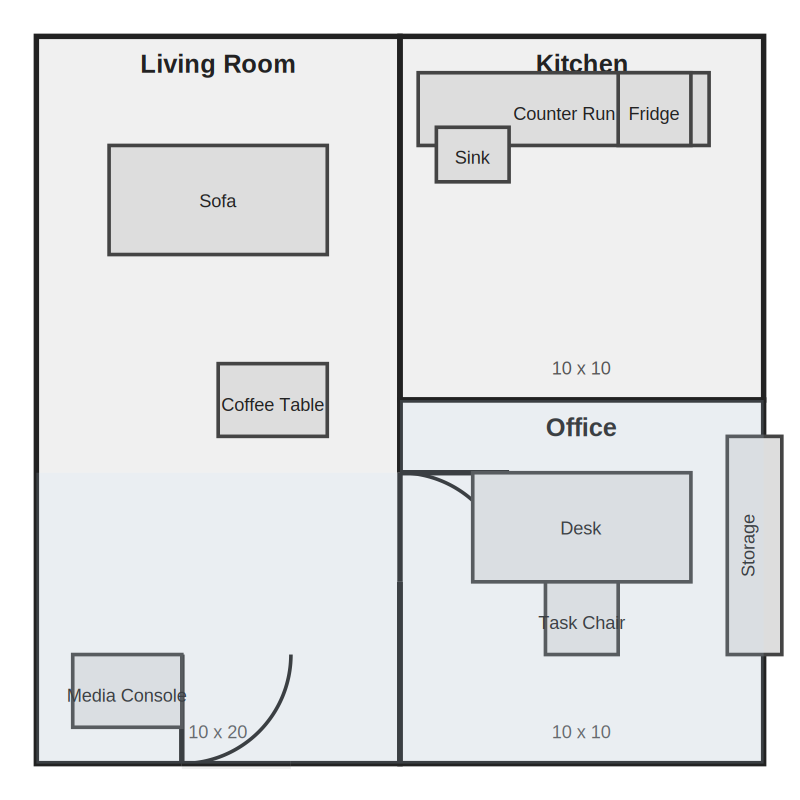

### Whole-plan panorama options

#### option_1

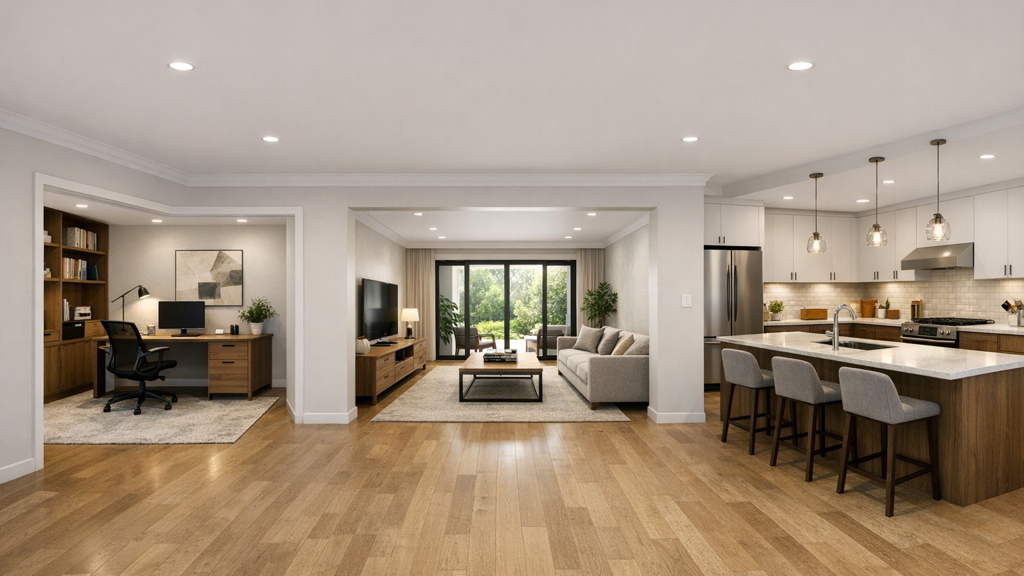

#### option_2

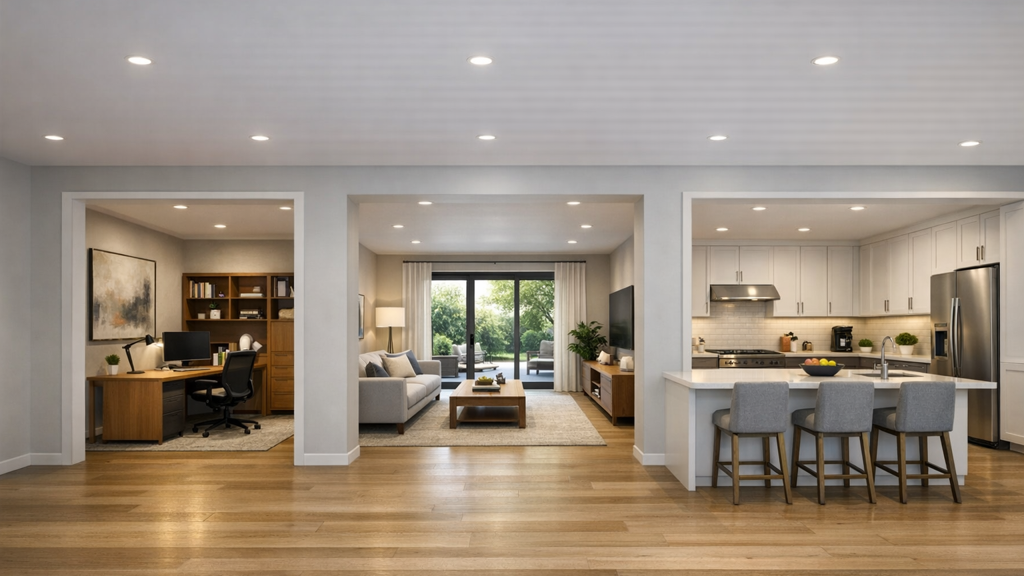

{'authoritative_svg': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.svg',
 'displayed_floor_plan': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.svg',
 'display_mode': 'svg',
 'png_placeholder': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/floorplan_20260516_142831_ecd3f7d2.png',
 'panorama_options': {'option_1': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/panorama/panorama_20260516_142928_1c7c8612_option_1.png',
  'option_2': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin-left-right-center-panorama/outputs/notebook-floor-plan/panorama/panorama_20260516_142928_1c7c8612_option_2.png'}}

In [97]:
from IPython.display import Image, Markdown, SVG, display
from xml.parsers.expat import ExpatError

try:
    display(SVG(filename=str(local_svg_path)))
    floor_plan_display_path = local_svg_path
    floor_plan_display_mode = "svg"
except ExpatError:
    display(Image(filename=str(local_png_path)))
    floor_plan_display_path = local_png_path
    floor_plan_display_mode = "png_fallback"

display(Markdown("### Whole-plan panorama options"))
for label, local_path in local_panorama_paths.items():
    display(Markdown(f"#### {label}"))
    display(Image(filename=str(local_path)))

{
    "authoritative_svg": str(local_svg_path),
    "displayed_floor_plan": str(floor_plan_display_path),
    "display_mode": floor_plan_display_mode,
    "png_placeholder": str(local_png_path),
    "panorama_options": {label: str(path) for label, path in local_panorama_paths.items()},
}
